In [1]:
import sys
sys.path.insert(0, '..')
from support.paths import resolve
import pandas as pd
import os
import numpy as np
from joblib import Parallel, delayed


In [2]:
%run ../0_Config/0_variables.ipynb

In [3]:
# Read data
X_train = pd.read_parquet("Data/X_train.parquet")
X_validate = pd.read_parquet("Data/X_validate.parquet")
X_test = pd.read_parquet("Data/X_test.parquet")
y_train = pd.read_parquet("Data/y_train.parquet")
y_validate = pd.read_parquet("Data/y_validate.parquet")
y_test = pd.read_parquet("Data/y_test.parquet")

# 1D sample-weight array of shape (n_train_rows,) — not a feature, never enters X_train.
# Each entry scales how much that row contributes to the loss during LightGBM training.
# linspace(0, 1.5, n) spaces exponents evenly across rows (oldest → newest), so
# exp() produces weights rising from 1.0 (oldest row) to ~4.5 (newest row),
# assuming X_train and y_train are aligned chronologically for training rows.
# Use X_train length because the weights correspond to training row order.
_chronological_weights = np.exp(np.linspace(0.0, 1.5, len(X_train))).astype(np.float32)

def _create_y_derivatives_per_target_col(horizon: int):
    """Compute all y (target) transformations for a given horizon."""
    
    target_col = f"h{horizon}"
    
    PRICE_TRANSFORM_SCALE = 100
    STANDARD_CLIP_PERCENTILE = 97.0
    POSITIVE_SPIKE_THRESHOLD = 150.0
    NEGATIVE_PRICE_THRESHOLD = 0.0
    POSITIVE_SPIKE_UPWEIGHT = 10.0
    NEGATIVE_SPIKE_UPWEIGHT = 7.0

    # y_train/y_validate hold all horizons as columns; slice the one being fitted
    # and convert to float32 to match LightGBM's expected dtype
    y_train_individual_target = y_train[target_col].values.astype(np.float32)
    y_validate_individual_target = y_validate[target_col].values.astype(np.float32)

    # Compute sample weights for standard model training
    # Returns a 1D sample-weight array of shape (n_train_rows,) combining two effects:
    #   - recency: weights already rise from 1.0 → ~4.5 via _chronological_weights
    #   - spike rows (price > threshold) are further multiplied by 3x
    # Net result: a recent spike row is weighted up to ~13.4x vs an old normal row,
    # preventing the standard model's loss from treating spikes as negligible noise.
    y_train_loss_weights = _chronological_weights.astype(np.float32)
    y_train_full_range_loss_weights = (_chronological_weights * np.where(y_train_individual_target > POSITIVE_SPIKE_THRESHOLD, 3.0, 1.0)).astype(np.float32)
    y_train_positive_spike_loss_weights = (_chronological_weights * np.where(y_train_individual_target > POSITIVE_SPIKE_THRESHOLD, POSITIVE_SPIKE_UPWEIGHT, 1.0)).astype(np.float32)
    y_train_negative_spike_loss_weights = (_chronological_weights * np.where(y_train_individual_target > NEGATIVE_PRICE_THRESHOLD, NEGATIVE_SPIKE_UPWEIGHT, 1.0)).astype(np.float32)

    # Compute clip threshold from training data
    y_train_individual_clipped = float(np.percentile(y_train_individual_target, STANDARD_CLIP_PERCENTILE))

    # arcsinh(y / 100) is a variance-stabilising transform that compresses large values
    # while preserving sign — unlike log, it handles negative prices. np.minimum clips
    # at the 97th-percentile threshold before transforming so extreme spikes don't
    # dominate the standard model's loss; the spike models handle those separately.
    y_train_individual_clipped_transformed = np.arcsinh(np.minimum(y_train_individual_target, y_train_individual_clipped) / PRICE_TRANSFORM_SCALE).astype(np.float32)
    y_validation_individual_clipped_transformed = np.arcsinh(np.minimum(y_validate_individual_target, y_train_individual_clipped) / PRICE_TRANSFORM_SCALE).astype(np.float32)

    # Same arcsinh transform but on the uncapped target — full price range including
    # extreme spikes and negative prices, which the specialist models are trained on.
    y_train_individual_unclipped_transformed = np.arcsinh(y_train_individual_target / PRICE_TRANSFORM_SCALE).astype(np.float32)
    y_validation_individual_unclipped_transformed = np.arcsinh(y_validate_individual_target / PRICE_TRANSFORM_SCALE).astype(np.float32)

    # Compute positive spike labels
    positive_spike_labels_train = (y_train_individual_target > POSITIVE_SPIKE_THRESHOLD).astype(np.float32)
    positive_spike_labels_validate = (y_validate_individual_target > POSITIVE_SPIKE_THRESHOLD).astype(np.float32)

    # Compute negative spike labels
    negative_spike_labels_train = (y_train_individual_target < NEGATIVE_PRICE_THRESHOLD).astype(np.float32)
    negative_spike_labels_validate = (y_validate_individual_target < NEGATIVE_PRICE_THRESHOLD).astype(np.float32)

    return {
        # 1 - target clipped and transformed
        'y_train_individual_clipped_transformed': y_train_individual_clipped_transformed,
        'y_validation_individual_clipped_transformed': y_validation_individual_clipped_transformed,

        # 2 - target no clipped but transformed
        'y_train_individual_unclipped_transformed': y_train_individual_unclipped_transformed,
        'y_validation_individual_unclipped_transformed': y_validation_individual_unclipped_transformed,
        
        # 3 - Positive target spike labels
        'positive_spike_labels_train': positive_spike_labels_train,
        'positive_spike_labels_validate': positive_spike_labels_validate,

        # 4 - Negative target spike labels
        'negative_spike_labels_train': negative_spike_labels_train,
        'negative_spike_labels_validate': negative_spike_labels_validate,

        # 5 - Weighting curve of target inc recency and spikes
        'y_train_loss_weights': y_train_loss_weights,
        'y_train_full_range_loss_weights': y_train_full_range_loss_weights,
        'y_train_positive_spike_loss_weights': y_train_positive_spike_loss_weights,
        'y_train_negative_spike_loss_weights': y_train_negative_spike_loss_weights
    }





horizon_list = list(range(1, int(os.environ["N_HORIZONS"]) + 1))

derived_targets = Parallel(n_jobs=-1, prefer="threads")(
    delayed(_create_y_derivatives_per_target_col)(h) for h in horizon_list
)

derived_targets = dict(zip(horizon_list, derived_targets))


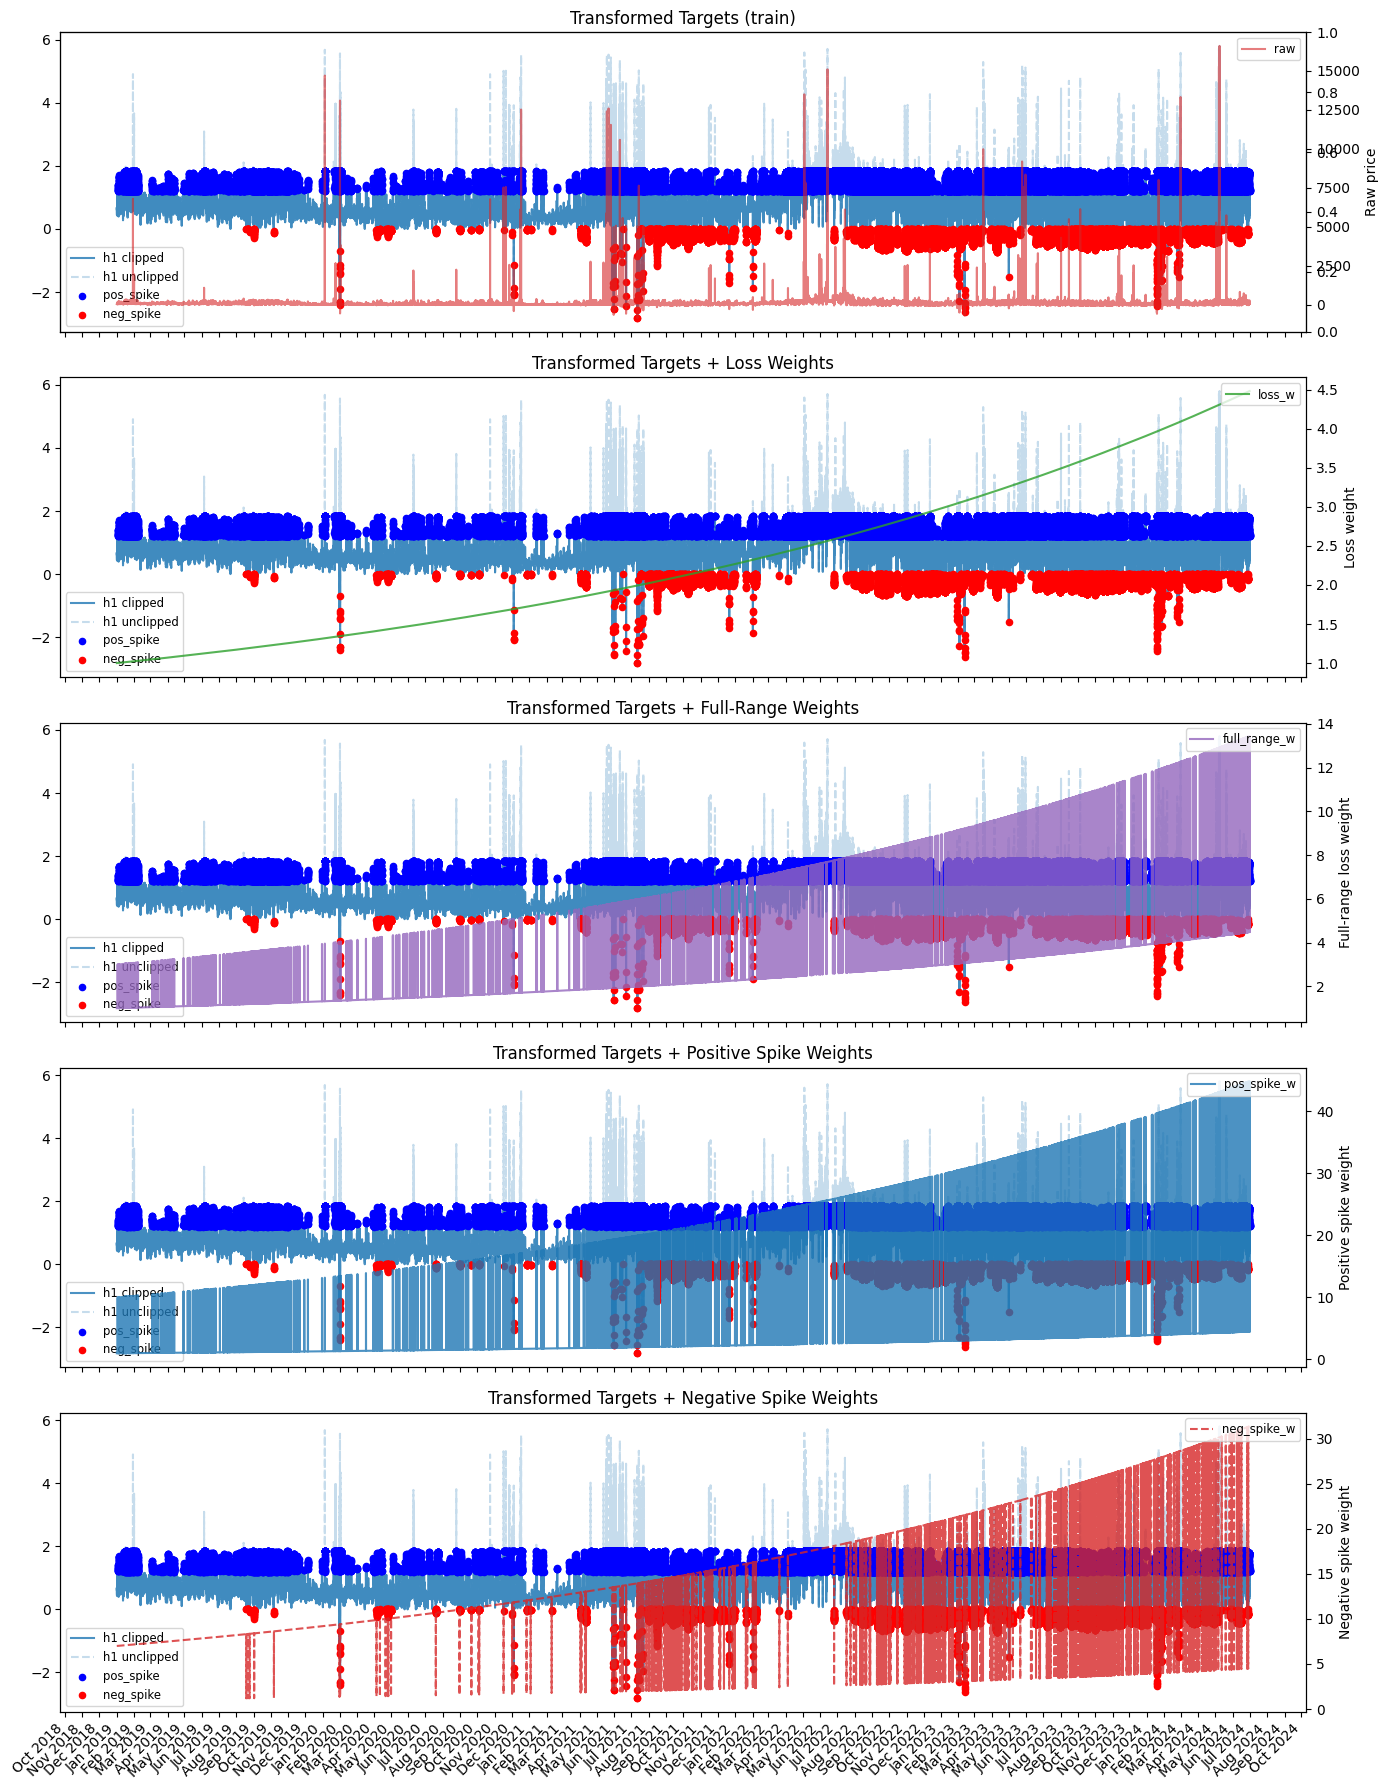

In [4]:
# Add a plotting cell to visualise derived targets for the first horizon (datetime x-axis)
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Prepare a figure with subplots that each replicate the transformed-target plot style
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)
palette = sns.color_palette('tab10', n_colors=1)

# Only plot the first horizon
h = horizon_list[0]
d = derived_targets[h]

# Use the training index for x-axis (convertable to datetime)
try:
    x = pd.to_datetime(X_train.index[:len(d['y_train_loss_weights'])])
except Exception:
    x = pd.RangeIndex(start=0, stop=len(d['y_train_loss_weights']))

# Common helper to draw the transformed target base plot on an axis
def _draw_base_plot(ax):
    ax.plot(x, d['y_train_individual_clipped_transformed'], color=palette[0], alpha=0.8, label=f'h{h} clipped')
    ax.plot(x, d['y_train_individual_unclipped_transformed'], color=palette[0], alpha=0.25, linestyle='--', label=f'h{h} unclipped')
    pos_idx = np.where(d['positive_spike_labels_train'] == 1)[0]
    neg_idx = np.where(d['negative_spike_labels_train'] == 1)[0]
    if len(pos_idx) > 0:
        ax.scatter(x[pos_idx], d['y_train_individual_clipped_transformed'][pos_idx], color='blue', s=20, label='pos_spike', zorder=5)
    if len(neg_idx) > 0:
        ax.scatter(x[neg_idx], d['y_train_individual_clipped_transformed'][neg_idx], color='red', s=20, label='neg_spike', zorder=5)
    ax.legend(fontsize='small')

# Plot 1: transformed targets only with raw overlay
_draw_base_plot(axes[0])
axes[0].set_title('Transformed Targets (train)')
raw_axis = axes[0].twinx()
if f'h{h}' in y_train.columns:
    raw = y_train[f'h{h}'].values[:len(x)]
    ax_raw = axes[0].twinx()
    ax_raw.plot(x, raw, color='tab:red', alpha=0.6, label='raw')
    ax_raw.set_ylabel('Raw price')
    ax_raw.legend(loc='upper right', fontsize='small')

# Plot 2: transformed targets with base loss weights overlay
_draw_base_plot(axes[1])
weight_axis = axes[1].twinx()
weight_axis.plot(x, d['y_train_loss_weights'], color='tab:green', alpha=0.8, label='loss_w')
weight_axis.set_ylabel('Loss weight')
axes[1].set_title('Transformed Targets + Loss Weights')
weight_axis.legend(loc='upper right', fontsize='small')

# Plot 3: transformed targets with full-range weights overlay
_draw_base_plot(axes[2])
weight_axis = axes[2].twinx()
weight_axis.plot(x, d['y_train_full_range_loss_weights'], color='tab:purple', alpha=0.8, label='full_range_w')
weight_axis.set_ylabel('Full-range loss weight')
axes[2].set_title('Transformed Targets + Full-Range Weights')
weight_axis.legend(loc='upper right', fontsize='small')

# Plot 4: transformed targets with positive spike-specific weights overlay
_draw_base_plot(axes[3])
weight_axis = axes[3].twinx()
weight_axis.plot(x, d['y_train_positive_spike_loss_weights'], color='tab:blue', alpha=0.8, label='pos_spike_w')
weight_axis.set_ylabel('Positive spike weight')
axes[3].set_title('Transformed Targets + Positive Spike Weights')
weight_axis.legend(loc='upper right', fontsize='small')

# Plot 5: transformed targets with negative spike-specific weights overlay
_draw_base_plot(axes[4])
weight_axis = axes[4].twinx()
weight_axis.plot(x, d['y_train_negative_spike_loss_weights'], color='tab:red', alpha=0.8, linestyle='--', label='neg_spike_w')
weight_axis.set_ylabel('Negative spike weight')
axes[4].set_title('Transformed Targets + Negative Spike Weights')
weight_axis.legend(loc='upper right', fontsize='small')

# Format x-axis as month and year
if hasattr(x, 'dtype') and (np.issubdtype(getattr(x, 'dtype'), np.datetime64) or isinstance(x[0], (np.datetime64,))):
    axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(axes[-1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()